In [22]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:

import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import joblib
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [24]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [25]:
print(df.shape)
print(df.info())
df.head()

(118, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118 entries, 1949-01-01 to 1960-12-01
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    118 non-null    int64  
 1   month          118 non-null    int32  
 2   quater         118 non-null    int32  
 3   lag1           117 non-null    float64
 4   lag2           116 non-null    float64
 5   lag3           115 non-null    float64
 6   rolling_mean3  116 non-null    float64
 7   rolling_std3   116 non-null    float64
 8   rolling_mean6  113 non-null    float64
 9   rolling_std6   113 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 9.2 KB
None


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [26]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.bfill(inplace=True)
print(df.shape)
df.head()

#Passengers      0
month            0
quater           0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0
(118, 10)


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-02-01,118,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-03-01,132,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277


In [27]:
train,test= df.iloc[:-12,:], df.iloc[-12:,:]
x_train,y_train= train.drop(columns=['#Passengers']), train['#Passengers']
x_test,y_test= test.drop(columns=['#Passengers']), test['#Passengers']

print(x_train.shape)
print(x_test.shape)
x_train.head()

(106, 9)
(12, 9)


,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,
1949-01-01,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-02-01,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-03-01,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-04-01,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277
1949-05-01,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277


In [28]:
print(x_test.isnull().sum())
print(x_test.duplicated().sum())
print(x_test.info())
x_test.describe()

month            0
quater           0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 1959-09-01 to 1960-12-01
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          12 non-null     int32  
 1   quater         12 non-null     int32  
 2   lag1           12 non-null     float64
 3   lag2           12 non-null     float64
 4   lag3           12 non-null     float64
 5   rolling_mean3  12 non-null     float64
 6   rolling_std3   12 non-null     float64
 7   rolling_mean6  12 non-null     float64
 8   rolling_std6   12 non-null     float64
dtypes: float64(7), int32(2)
memory usage: 864.0 bytes
None


,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
count,12.000000,12.000000,12.00000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.833333,2.583333,481.50000,494.666667,491.666667,482.361111,53.212966,478.708333,71.321560
std,3.639014,1.164500,82.98576,79.614221,79.744288,63.947020,27.652985,32.867205,19.257241
min,1.000000,1.000000,390.00000,391.000000,391.000000,405.000000,13.114877,426.333333,29.357566
25%,3.750000,1.750000,414.50000,418.500000,418.500000,427.666667,33.891013,458.791667,63.038836
50%,7.500000,3.000000,462.00000,485.500000,467.500000,474.000000,55.634950,477.000000,69.663089
75%,9.250000,3.250000,541.00000,550.750000,550.750000,527.333333,65.507895,508.125000,87.921564
max,12.000000,4.000000,622.00000,622.000000,622.000000,587.666667,108.154211,525.166667,97.072482


In [29]:
model = LGBMRegressor(force_col_wise=True,random_state=42)
model.fit(x_train, y_train)

LGBMRegressor(force_col_wise=True, random_state=42)

In [30]:
pred= model.predict(x_test)
pred= pd.Series(pred, index= x_test.index)

In [31]:
pred

Month
1959-09-01    394.988307
1959-10-01    362.606900
1960-01-01    452.053900
1960-02-01    418.574326
1960-03-01    418.574326
1960-04-01    434.404592
1960-06-01    463.874091
1960-07-01    468.789299
1960-08-01    468.789299
1960-09-01    394.988307
1960-11-01    362.606900
1960-12-01    362.606900
dtype: float64

In [32]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

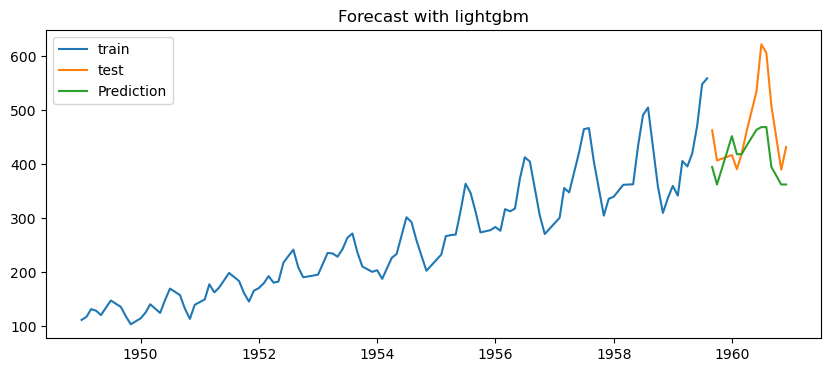

mean absolute error: 64.45
mean absolute percentage error: 13.0%
r2 score: -0.06
root mean squared error: 79.05


,mae,mape,r2,rmse
0,64.45,13.0,-0.06,79.05


In [33]:
model_evaluator(y_train,y_test,pred, 'lightgbm')

In [34]:
# Fine tuning lightgbm

split= TimeSeriesSplit(n_splits=5)
param_grid={
    "num_leaves": list(range(5,16,2)),
    "max_depth": list(range(2,6)),
    "n_estimators": list(range(100,5000,100)),
    "min_child_samples": list(range(2, 11,2)),
    "subsample": list(np.arange(0.6, 1.0, 0.1)),
    "colsample_bytree": list(np.arange(0.5, 1.0, 0.1)),
    "reg_alpha": list(np.arange(0.0, 1.0, 0.25)),
    "reg_lambda": list(np.arange(0.0, 2.0, 0.25)),
}
model= LGBMRegressor(force_col_wise=True,
                    random_state=42,
                    verbosity=-1)

grid= RandomizedSearchCV(model, param_grid,cv=split,n_iter=40, n_jobs=-1, scoring='neg_mean_absolute_error',verbose=1)

In [35]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LGBMRegressor(force_col_wise=True, random_state=42,
                                           verbosity=-1),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.6, 0.7,
                                                             0.7999999999999999,
                                                             0.8999999999999999],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_child_samples': [2, 4, 6, 8, 10],
                                        'n_estimators': [10...0,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100, 1200,
                                                         1300, 1400, 1500, 1600,
                                                         1700, 1800, 1900, 2000,
                                                         2100, 2200, 2300, 2400,
                                                         2500, 2600, 2700, 2800,
                                                         2900, 3000, ...],
                                        'num_leaves': [5, 7, 9, 11, 13, 15],
                                        'reg_alpha': [0.0, 0.25, 0.5, 0.75],
                                        'reg_lambda': [0.0, 0.25, 0.5, 0.75,
                                                       1.0, 1.25, 1.5, 1.75],
                                        'subsample': [0.6, 0.7,
                                                      0.7999999999999999,
                                                      0.8999999999999999]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [36]:
grid.best_score_

-34.92368640604532

In [37]:
param= grid.best_params_
param

{'subsample': 0.7999999999999999,
 'reg_lambda': 1.5,
 'reg_alpha': 0.75,
 'num_leaves': 13,
 'n_estimators': 1900,
 'min_child_samples': 2,
 'max_depth': 2,
 'colsample_bytree': 0.7999999999999999}

In [38]:
pred= grid.predict(x_test)
pred= pd.Series(pred, index=x_test.index)
pred

Month
1959-09-01    484.092630
1959-10-01    415.829429
1960-01-01    471.852112
1960-02-01    449.242169
1960-03-01    444.165496
1960-04-01    483.015766
1960-06-01    561.010310
1960-07-01    555.568321
1960-08-01    556.535501
1960-09-01    486.527474
1960-11-01    417.796018
1960-12-01    412.350415
dtype: float64

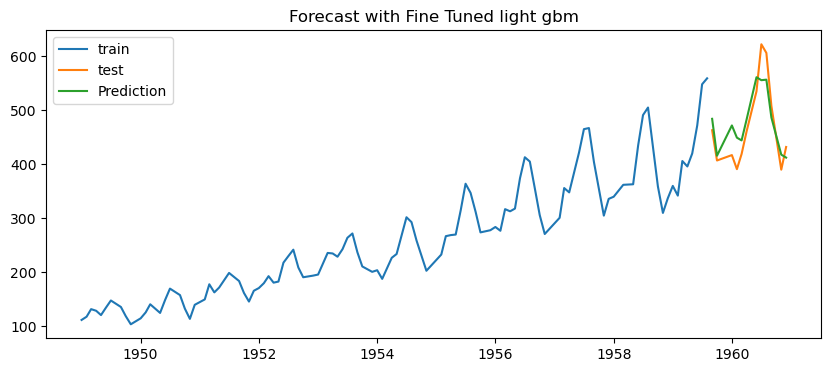

mean absolute error: 33.42
mean absolute percentage error: 7.000000000000001%
r2 score: 0.76
root mean squared error: 37.86


In [39]:
lgbm_metric=model_evaluator(y_train,y_test,pred, 'Fine Tuned light gbm')

In [40]:
lgbm_metric.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\lgbm_metric.csv')

In [41]:
# final model

final_model= LGBMRegressor(**param)
final_model.fit(df.drop(columns=['#Passengers']), df['#Passengers'])

LGBMRegressor(colsample_bytree=0.7999999999999999, max_depth=2,
              min_child_samples=2, n_estimators=1900, num_leaves=13,
              reg_alpha=0.75, reg_lambda=1.5, subsample=0.7999999999999999)

In [42]:
future_data= pd.date_range(start= '1961-01-01' , freq='MS', periods=12)
future_data= pd.Series(index= future_data)
future_data.index

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [43]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_data.index:

        month_number = date.month
        quarter_number =date.quarter

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]


        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

      

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
           
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_data.index, name=target_col)

    return future_exog, forecast

In [44]:
history = df["#Passengers"].ffill()  

future_exog, forecast = build_exog_row(final_model, history, future_data)


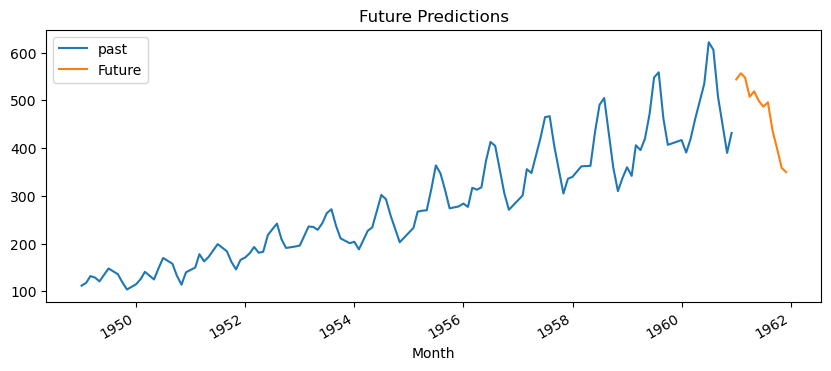

In [45]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='past')
forecast.plot(label='Future')

plt.legend()
plt.title('Future Predictions')
plt.show()

In [46]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\lightgbm.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\lightgbm.pkl']

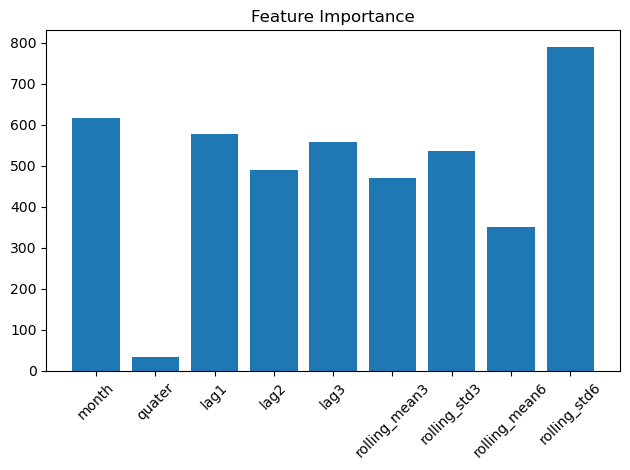

In [47]:
# Feature importance

importance= final_model.feature_importances_

plt.bar( x_train.columns, importance)

plt.title('Feature Importance')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

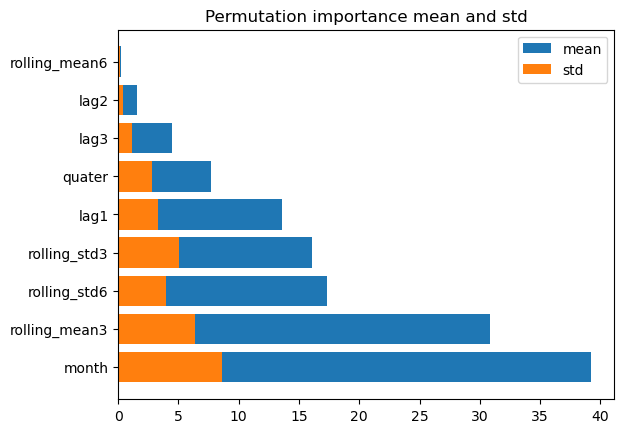

In [48]:
# Permutation importance 

p_imp= permutation_importance(final_model,x_test,y_test,
                              scoring='neg_mean_absolute_error',
                              n_repeats= 30,
                              n_jobs= -1)
values= {
  'features': x_test.columns,
  'mean': p_imp.importances_mean,
  'std': p_imp.importances_std
}
p_imp= pd.DataFrame(values)
p_imp=p_imp.sort_values('mean', ascending=False)
plt.barh(p_imp['features'], p_imp['mean'], label='mean')
plt.barh(p_imp['features'], p_imp['std'], label='std')

plt.legend()
plt.title('Permutation importance mean and std')
plt.show()

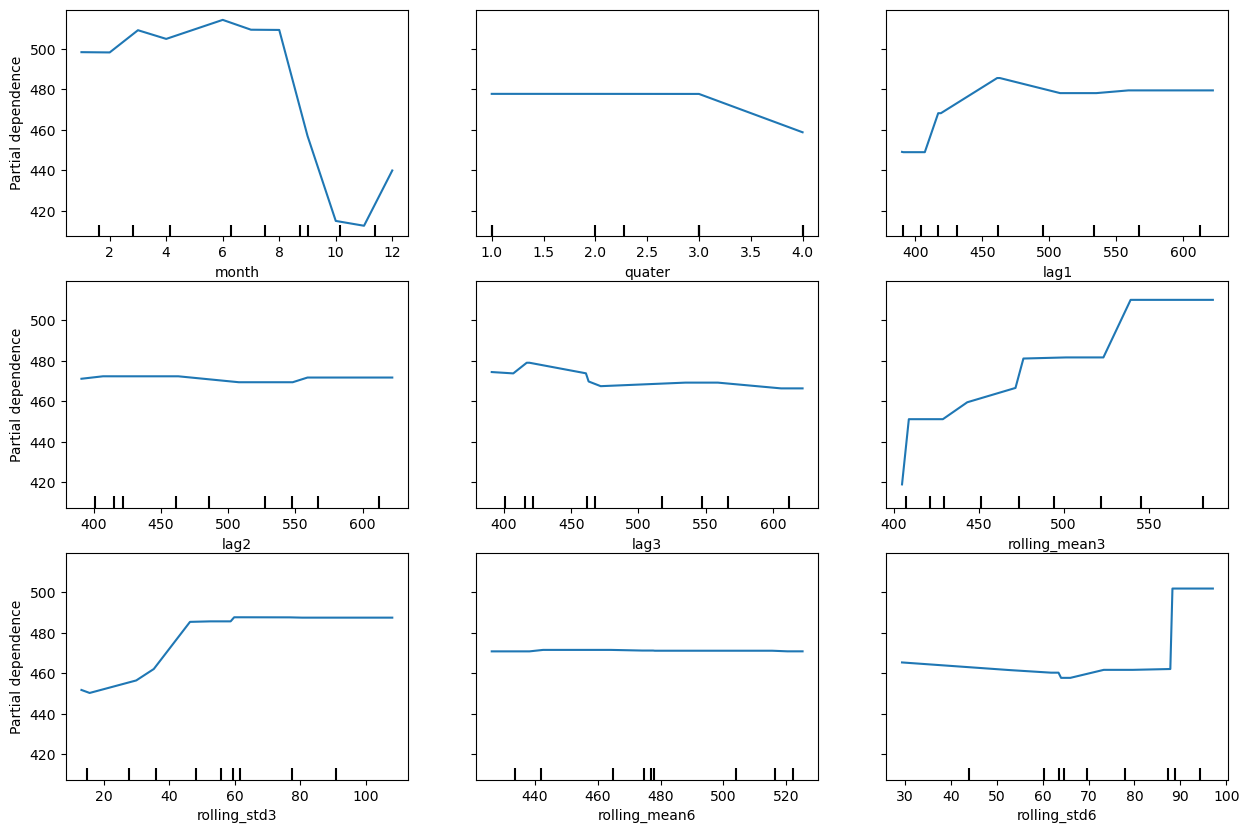

In [49]:
# partial dependency

fig,axes= plt.subplots(figsize=(15,10))

PartialDependenceDisplay.from_estimator(
                final_model, x_test,
                features= list(x_test.columns),
                feature_names= list(x_test.columns),
                grid_resolution= 50,
                n_cols= 3,
                ax= axes
)
plt.show()